#### Imports

In [1]:
!export PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True

In [2]:
import matplotlib.pyplot as plt

In [3]:
import random
import json
import copy
import time
import math
from collections import Counter
from pycocotools.coco import COCO
import kagglehub

In [4]:
import spacy

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torchvision import datasets
from torch.utils.data import random_split
from torch.utils.data import DataLoader, Dataset
from torch.utils.tensorboard import SummaryWriter

#### Loading the dataset

In [8]:
# path = kagglehub.dataset_download("awsaf49/coco-2017-dataset")

# print("Path to dataset files:", path)

#### Transforming and splitting the dataset

In [12]:
image_size = 256
batch_size = 128

In [13]:
nlp = spacy.load("en_core_web_sm")
def preprocess_caption(caption, max_length=100, sos_token='<sos>', eos_token='<eos>'):
  lowered_caption = caption.lower()

  tokenized_caption = [token.text for token in nlp.tokenizer(lowered_caption)]

  trimmed_caption = tokenized_caption[:max_length]

  stop_end_captions = [sos_token] + trimmed_caption + [eos_token]

  return stop_end_captions

In [14]:
class TransformCaptions(nn.Module):
    def __call__(self, sample):
        rand_index = random.randint(0, len(sample) - 1)
        caption = sample[rand_index]
        return preprocess_caption(caption)

In [15]:
weights = torchvision.models.ResNet18_Weights.IMAGENET1K_V1

transform = weights.transforms()

# transform = transforms.Compose([
#     transforms.Resize((image_size, image_size)),
#     transforms.ToTensor(),
# ])

In [16]:
train_images_path = '/home/obojana/.cache/kagglehub/datasets/awsaf49/coco-2017-dataset/versions/2/coco2017/train2017'
train_ann_path = '/home/obojana/.cache/kagglehub/datasets/awsaf49/coco-2017-dataset/versions/2/coco2017/annotations/captions_train2017.json'

train_dataset = datasets.CocoCaptions(
    root=train_images_path,
    annFile=train_ann_path,
    transform=transform,
    target_transform=TransformCaptions(),
)

loading annotations into memory...
Done (t=0.67s)
creating index...
index created!


In [17]:
val_images_path = '/home/obojana/.cache/kagglehub/datasets/awsaf49/coco-2017-dataset/versions/2/coco2017/val2017'
val_ann_path = '/home/obojana/.cache/kagglehub/datasets/awsaf49/coco-2017-dataset/versions/2/coco2017/annotations/captions_val2017.json'

val_dataset = datasets.CocoCaptions(
    root=val_images_path,
    annFile=val_ann_path,
    transform=transform,
    target_transform=TransformCaptions()
)

loading annotations into memory...
Done (t=0.04s)
creating index...
index created!


In [18]:
train_size = int(0.9 * len(train_dataset))
test_size = len(train_dataset) - train_size
train_dataset, test_dataset = random_split(train_dataset, [train_size, test_size])

#### Making vocabulary

In [19]:
min_freq = 2
unk_token = "<unk>"
pad_token = "<pad>"
sos_token = "<sos>"
eos_token = "<eos>"

In [20]:
train_captions = [el[1] for el in train_dataset]

In [21]:
word_counter = Counter()

for caption in train_captions:
    word_counter.update(caption)

filtered_words = {word for word, count in word_counter.items() if count >= min_freq}

special_tokens = [unk_token, pad_token, eos_token, sos_token]
vocab = special_tokens + list(filtered_words)
token_to_idx = {word: idx for idx, word in enumerate(vocab)}

In [22]:
vocab_size = len(vocab)
vocab_size

8089

#### Visualize

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.64].


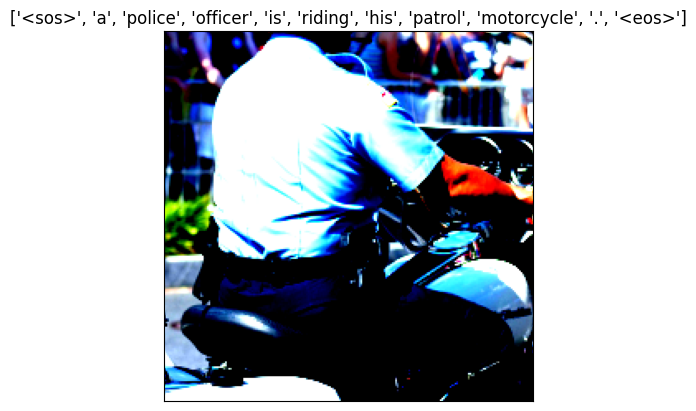

In [23]:
plt.imshow(train_dataset[0][0].permute(1, 2, 0))
plt.title(train_dataset[0][1])
plt.xticks([])
plt.yticks([])
plt.show()

#### Sizes

In [25]:
len(train_dataset), len(val_dataset), len(test_dataset)

(106458, 5000, 11829)

#### Encoder

In [35]:
class Encoder(nn.Module):
    def __init__(self, embedding_size):
        super(Encoder, self).__init__()

        resnet = torchvision.models.resnet18(weights='DEFAULT')
        modules = list(resnet.children())[:-1]
        self.resnet = nn.Sequential(*modules)
        self.fc = nn.Linear(resnet.fc.in_features, embedding_size)

        self.fine_tune()

    def forward(self, images):
        features = self.resnet(images)
        features = features.view(features.size(0), -1)
        features = self.fc(features)
        return features

    def fine_tune(self):
        for p in self.resnet.parameters():
            p.requires_grad = True

        for p in self.fc.parameters():
            p.requires_grad = True

#### Decoder

In [36]:
class Decoder(nn.Module):
  def __init__(self, embedding_size, vocab_size, hidden_size, num_layers):
    super(Decoder, self).__init__()

    self.embedding = nn.Embedding(vocab_size, embedding_size)
    self.lstm = nn.LSTM(embedding_size, hidden_size, num_layers, batch_first=True)
    self.fc = nn.Linear(hidden_size, vocab_size)

  def forward(self, features, captions):
    embeddings = self.embedding(captions)
    embeddings = torch.cat((features.unsqueeze(1), embeddings), dim=1)
    hiddens, _ = self.lstm(embeddings)
    outputs = self.fc(hiddens)
    return outputs

#### Encoder-Decoder

In [37]:
class EncoderDecoder(nn.Module):
  def __init__(self, embedding_size, vocab_size, hidden_size, num_layers):
    super(EncoderDecoder, self).__init__()

    self.encoder = Encoder(embedding_size)
    self.decoder = Decoder(embedding_size, vocab_size, hidden_size, num_layers)

  def forward(self, images, captions):
    features = self.encoder(images)
    outputs = self.decoder(features, captions)
    return outputs

#### DataLoaders

In [38]:
def collate_fn(batch):
    images, captions = list(zip(*batch))

    max_length = max(len(seq) for seq in captions)

    indexed_captions = [
        [token_to_idx.get(word, token_to_idx["<unk>"]) for word in seq]
        for seq in captions
    ]

    padded_captions = [seq + [token_to_idx["<pad>"]] * (max_length - len(seq)) for seq in indexed_captions]

    padded_captions = torch.tensor(padded_captions, dtype=torch.long)
    images = torch.stack(images, dim=0)

    return images, padded_captions

In [39]:
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=collate_fn,
    shuffle=True,
    pin_memory=True,
    num_workers=2
)

In [40]:
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=collate_fn,
    shuffle=False,
    pin_memory=True,
    num_workers=2
)

#### Training

In [41]:
embedding_size = 256
hidden_size = 512
num_layers = 2
lr = 0.01
num_epochs = 100
start_epoch = 0

In [42]:
torch.backends.cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [43]:
model = EncoderDecoder(embedding_size, vocab_size, hidden_size, num_layers).to(device)

In [44]:
# def init_weights(m):
#     if isinstance(m, nn.LSTM):
#         # Apply Xavier initialization to LSTM layers
#         for name, param in m.named_parameters():
#             if 'weight_ih' in name:  # Input-to-hidden weights
#                 nn.init.xavier_uniform_(param.data)  # Xavier uniform
#             elif 'weight_hh' in name:  # Hidden-to-hidden weights
#                 nn.init.xavier_uniform_(param.data)  # Xavier uniform
#             elif 'bias' in name:
#                 nn.init.constant_(param.data, 0)  # Bias initialized to zero

#     elif isinstance(m, nn.Embedding):
#         # Apply Uniform initialization to Embedding layers
#         nn.init.uniform_(m.weight.data, -0.1, 0.1)  # Uniform initialization

#     elif isinstance(m, nn.Linear):
#         # Apply Xavier initialization to Linear layers (if present)
#         nn.init.xavier_uniform_(m.weight.data)
#         if m.bias is not None:
#             nn.init.constant_(m.bias.data, 0)  # Bias initialized to zero

#     elif isinstance(m, nn.Conv2d):
#         # Apply Xavier initialization to Conv2D layers
#         nn.init.kaiming_uniform_(m.weight.data, a=math.sqrt(5))  # Kaiming uniform
#         if m.bias is not None:
#             nn.init.constant_(m.bias.data, 0)  # Bias initialized to zero

# model.apply(init_weights)

In [45]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total number of trainable parameters: {trainable_params}')

Total number of trainable parameters: 21206489


In [46]:
criterion = nn.CrossEntropyLoss(ignore_index=token_to_idx["<pad>"]).cuda() if torch.cuda.is_available() else nn.CrossEntropyLoss(ignore_index=token_to_idx["<pad>"])
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [47]:
writer = SummaryWriter(log_dir="runs/image_captioning")

patience = 5
best_model_wts = copy.deepcopy(model.state_dict())
best_loss = float("inf")
epochs_since_improvement = 0

In [52]:
epoch = start_epoch
while epoch <= num_epochs:
  start_time = time.time()

  model.train()
  running_loss = 0.0
  train_samples = 0
  for idx, (images, captions) in enumerate(train_loader):
    images, captions = images.to(device), captions.to(device)

    batch_size = captions.size(0)

    optimizer.zero_grad()

    outputs = model(images, captions[:, :-1])

    loss = criterion(outputs.view(-1, vocab_size), captions.view(-1))
    running_loss += loss.item() * batch_size
    train_samples += batch_size

    loss.backward()
    optimizer.step()

  avg_train_loss = running_loss / train_samples
  writer.add_scalar("Loss/train", avg_train_loss, epoch)

  model.eval()
  val_loss = 0.0
  val_samples = 0
  with torch.no_grad():
    for idx, (images, captions) in enumerate(val_loader):
      images, captions = images.to(device), captions.to(device)

      batch_size = captions.size(0)

      outputs = model(images, captions[:, :-1])

      loss = criterion(outputs.view(-1, vocab_size), captions.view(-1))

      val_loss += loss.item() * batch_size
      val_samples += batch_size

  avg_val_loss = val_loss / val_samples
  writer.add_scalar("Loss/val", avg_val_loss, epoch)

  if avg_val_loss < best_loss:
      best_loss = avg_val_loss
      best_model_wts = copy.deepcopy(model.state_dict())
      epochs_since_improvement = 0
  else:
      epochs_since_improvement += 1

  torch.save({
      'epoch': epoch,
      'model_state_dict': model.state_dict(),
      'optimizer_state_dict': optimizer.state_dict(),
      'loss': avg_train_loss,
  }, f"checkpoint_epoch_{epoch}.pth")

  # Early stopping condition
  if epochs_since_improvement >= patience:
    print(f"Early stopping at epoch {epoch}")
    break

  epoch_time = time.time() - start_time
  print(f"Epoch {epoch}/{num_epochs - 1}, "
        f"Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, "
        f"Time: {epoch_time:.2f}s")

  epoch += 1

model.load_state_dict(best_model_wts)

writer.close()

checkpoint = torch.load(f'checkpoint_epoch_{epoch}.pth')
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
start_epoch = checkpoint['epoch'] + 1
epochs_since_improvement = 0

Epoch 20/99, Train Loss: 2.4895, Val Loss: 2.6233, Time: 167.44s
Epoch 21/99, Train Loss: 2.4893, Val Loss: 2.6393, Time: 174.46s
Epoch 22/99, Train Loss: 2.4891, Val Loss: 2.6433, Time: 166.87s
Epoch 23/99, Train Loss: 2.4815, Val Loss: 2.6564, Time: 171.76s
Early stopping at epoch 24


/tmp/ipykernel_2537770/3898896285.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(f'checkpoint_epoch_{epoch}.pth')


In [51]:
epochs_since_improvement = 0

(torch.Size([3, 5]), torch.Size([3, 5]))

In [ ]:
torch.cuda.empty_cache()

In [62]:
!tensorboard --logdir=/home/obojana/MAS_Image_Captioning/results_v0/runs/image_captioning

SyntaxError: cannot assign to expression (226303353.py, line 1)